# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [1]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


/Users/ronitdas/Documents/GitHub/homework-3-Fossilbullet/.hw3/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data Loading

In [2]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('/Users/ronitdas/Documents/GitHub/homework-3-Fossilbullet/data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="/Users/ronitdas/Documents/GitHub/homework-3-Fossilbullet/data/GSE139307.pkl")
df_aging = pd.DataFrame(df_aging)
# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset
print(X_clf.shape, y_clf.shape)
print()
print(df_aging.shape)
print()
print(X_clf.isnull().sum())
print()
print(df_aging.columns[df_aging.isnull().any()].tolist())
print(X_clf.describe())
print(df_aging.describe())


Successfully loaded heart disease data with 1025 rows
(1025, 13) (1025,)

(37, 485516)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

['cg00121626', 'cg00198603', 'cg00259584', 'cg00394712', 'cg00461991', 'cg00614360', 'cg00893493', 'cg00931375', 'cg01037637', 'cg01147467', 'cg01278720', 'cg01413698', 'cg01424889', 'cg01550828', 'cg01582532', 'cg01675596', 'cg01780171', 'cg01813738', 'cg02000275', 'cg02018902', 'cg02052410', 'cg02155405', 'cg02321096', 'cg02389942', 'cg02470587', 'cg02553872', 'cg02587129', 'cg02789126', 'cg02856727', 'cg02925799', 'cg02943194', 'cg02987635', 'cg02988775', 'cg03131732', 'cg03163448', 'cg03185827', 'cg03347590', 'cg03799581', 'cg04006399', 'cg04192760', 'cg04359702', 'cg04434909', 'cg04466743', 'cg04490024', 'cg04585364', 'cg04600795', 'cg04656051', 'cg04685645', 'cg04740941', 'cg04852949', 'cg04862885', '

## Classification Task (Heart Disease)

Exploring classification dataset...


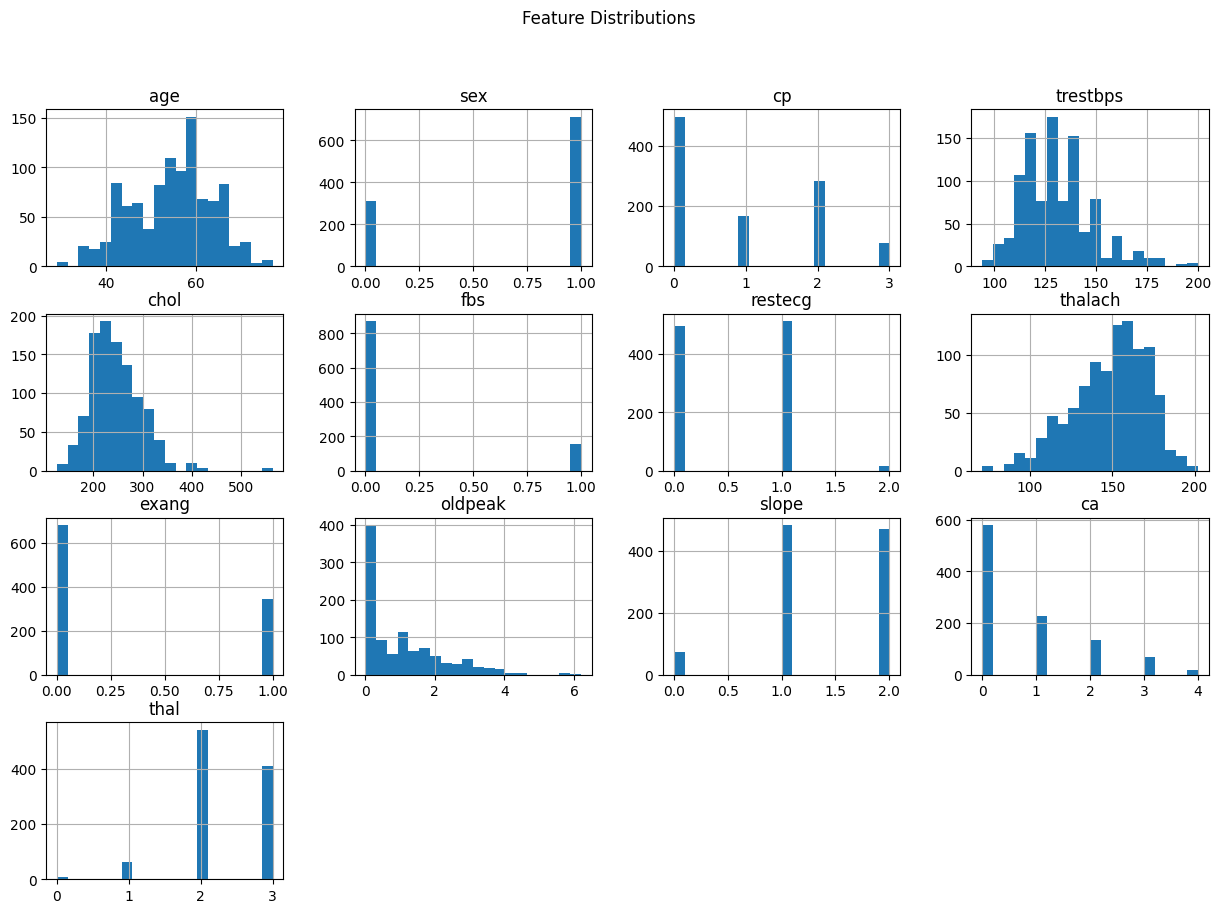

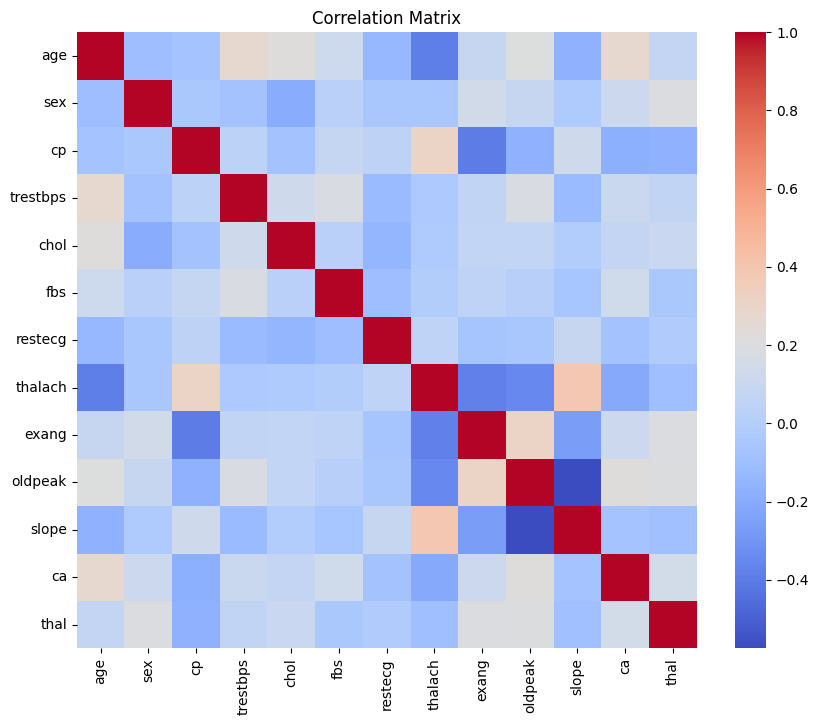

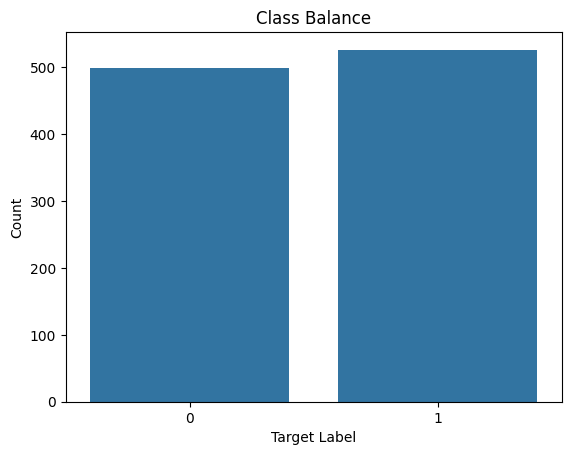

In [3]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)


In [22]:
# TODO: Split X_clf and y_clf into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf)

### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [24]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaling", StandardScaler()),
    ("pca", PCA()),
    ("model", svm_classifier(kernel="linear", C=0.8, degree=3, gamma=0.1))
])


### Kernel Experiments

In [26]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
metrics = []
for kerneltype in ["linear", "poly", "rbf"]:
    pipeline.set_params(model__kernel=kerneltype, model__C=0.8, model__degree=3, model__gamma=0.1)
    pipeline.fit(X_train, y_train)
    evaluationmetrics = evaluate_classifier(pipeline, X_test, y_test)
    metrics.append(evaluationmetrics)
    print(kerneltype.upper())
    print(evaluationmetrics)
    print()

#Best Model uses Poly kernel type
pipeline.set_params(model__kernel="poly", model__C=0.8, model__degree=3, model__gamma=0.1)
pipeline.fit(X_train, y_train)
    
    
    

LINEAR
{'Accuracy': 0.8521400778210116, 'Precision': 0.8163265306122449, 'Recall': 0.916030534351145, 'F1': 0.8633093525179856}

POLY
{'Accuracy': 0.9377431906614786, 'Precision': 0.9323308270676691, 'Recall': 0.9465648854961832, 'F1': 0.9393939393939394}

RBF
{'Accuracy': 0.9377431906614786, 'Precision': 0.9323308270676691, 'Recall': 0.9465648854961832, 'F1': 0.9393939393939394}



Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaling', StandardScaler()), ('pca', PCA()),
                ('model', SVC(C=0.8, gamma=0.1, kernel='poly'))])

### Classification Metrics and Visuals

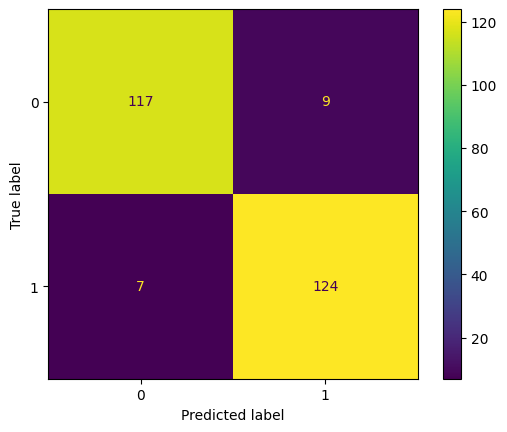

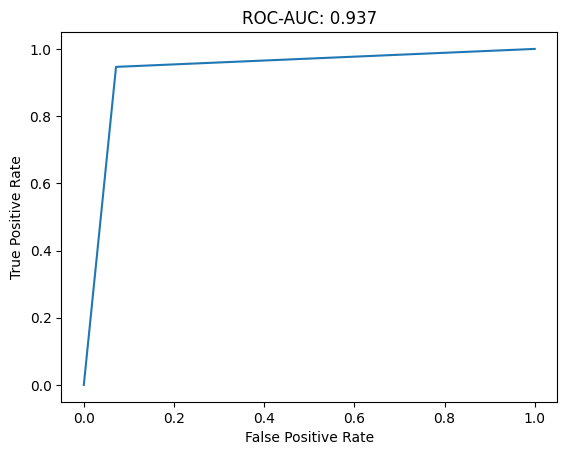

In [27]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve
predictions = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
precision = f1_score(y_test, predictions)

ROC_AUC = roc_auc_score(y_test, predictions)
fpr, tpr, thresholds = roc_curve(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm).plot()
plt.show()
plt.plot(fpr, tpr)
plt.title("ROC-AUC: " + str(ROC_AUC)[:5])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Hyperparameter Sensitivity

[{'Accuracy': 0.9416342412451362, 'Precision': 0.9393939393939394, 'Recall': 0.9465648854961832, 'F1': 0.9429657794676806}, {'Accuracy': 0.9377431906614786, 'Precision': 0.9323308270676691, 'Recall': 0.9465648854961832, 'F1': 0.9393939393939394}, {'Accuracy': 0.9299610894941635, 'Precision': 0.9185185185185185, 'Recall': 0.9465648854961832, 'F1': 0.9323308270676691}, {'Accuracy': 0.9105058365758755, 'Precision': 0.8913043478260869, 'Recall': 0.9389312977099237, 'F1': 0.9144981412639405}]


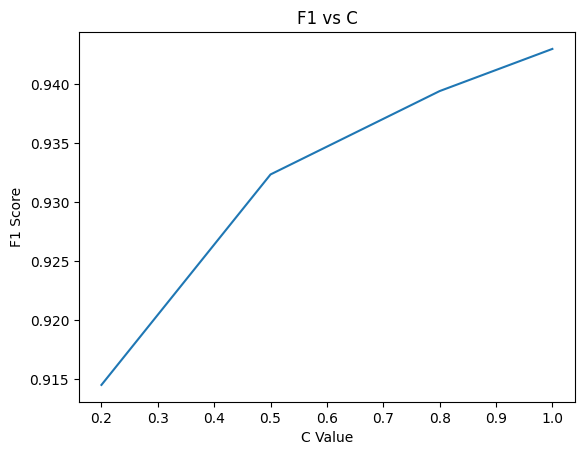

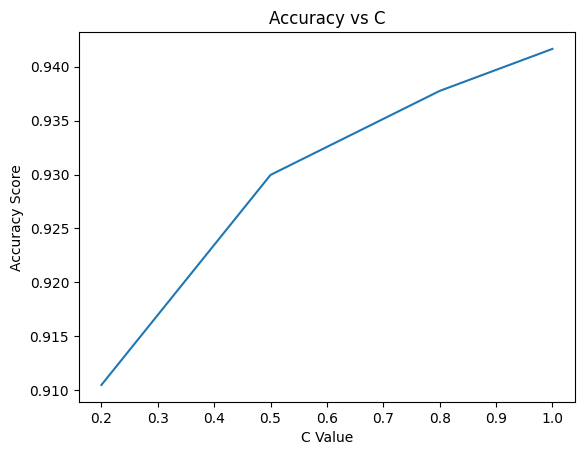

In [28]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
cgdmetrics = []
cvals = [1.0, 0.8, 0.5, 0.2]
for c in cvals:
    pipeline.set_params(model__kernel="poly", model__C=c, model__degree=3, model__gamma=0.1)
    pipeline.fit(X_train, y_train)
    cmetrics = evaluate_classifier(pipeline, X_test, y_test)
    cgdmetrics.append(cmetrics)

print(cgdmetrics)
f1scores = []
accuracyscores = []
for i in cgdmetrics:
    f1scores.append(i['F1'])
    accuracyscores.append(i['Accuracy'])
    
plt.plot(cvals, f1scores)
plt.title("F1 vs C")
plt.xlabel("C Value")
plt.ylabel("F1 Score")
plt.show()

plt.plot(cvals, accuracyscores)
plt.title("Accuracy vs C")
plt.xlabel("C Value")
plt.ylabel("Accuracy Score")
plt.show()

## Regression Task (Biological Aging)

In [47]:
# TODO: Separate target column "target" from features
# X_reg = df_aging.drop(columns=["target"])
# y_reg = df_aging["target"]
X_reg = df_aging.drop(columns=["age", "dataset", "tissue_type", "gender"])
y_reg = df_aging["age"]
X_reg = X_reg.dropna(axis=1, how="all")

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
# imputer = SimpleImputer(strategy="mean")
# X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)
imputer = SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# TODO: Split X_reg and y_reg into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg)



### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [48]:
# TODO: Build a leakage-free pipeline for regression
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_regressor(kernel=..., C=..., degree=..., gamma=...)),
# ])
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", svm_regressor(kernel="poly", C=1.0, degree=3, gamma=0.1))
    
])


### Kernel Experiments

In [49]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
kernelmetrics = []
for kerneltype in ["linear", "poly", 'rbf']:
    pipeline.set_params(model__kernel=kerneltype, model__C=1.0, model__degree=3, model__gamma=0.1)
    pipeline.fit(X_train, y_train)
    metrics = evaluate_regressor(pipeline, X_test, y_test)
    kernelmetrics.append(metrics)

pipeline.set_params(model__kernel="linear", model__C=1.0, model__degree=3, model__gamma=0.1)
pipeline.fit(X_train, y_train)

for metric, kerneltype in zip(kernelmetrics, ["linear", "poly", "rbf"]):
    print(kerneltype.upper())
    print(metric)
    print()

LINEAR
{'Mean Absolute Error': 7.72962067697073, 'Mean Squared Error': 93.58943627455295, 'R2': 0.002776384927512532}

POLY
{'Mean Absolute Error': 9.000504557007488, 'Mean Squared Error': 131.843708390397, 'R2': -0.4048343994714654}

RBF
{'Mean Absolute Error': 9.1, 'Mean Squared Error': 148.6100000000001, 'R2': -0.5834842834310081}



### Regression Metrics and Visuals

In [12]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
# plot_regression_results(...)
# plot_residuals(...)
predictions = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(mae, mse, r2)

plot_regression_results(y_test, predictions, filename="Regression Results Plot")
plot_residuals(y_test, predictions, filename="Residual Plot")

9.95275179023709 134.02438366202563 -0.5760158003530766


### Hyperparameter Sensitivity (Regression)

[0.009996330389504263, 0.009996330389504263, 0.009996330389504263, 0.009996330389504263]


[]

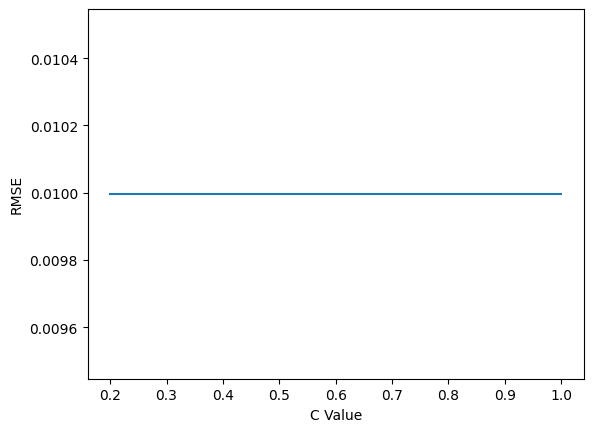

In [13]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
C = [1.0, 0.8, 0.5, 0.2]

rmsemetrics = []
for c in C:
    pipeline.set_params(model__C = c)
    pipeline.fit(X_test, y_test)
    metrics = evaluate_regressor(pipeline, X_test, y_test)
    rmsemetrics.append(metrics["Mean Squared Error"])

print(rmsemetrics)

plt.plot(C, rmsemetrics)
plt.xlabel("C Value")
plt.ylabel("RMSE")
plt.plot()